In [1]:
# imports
import tensorflow as tf
from tensorflow import keras as keras
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

2024-05-24 10:58:29.684159: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-24 10:58:29.684224: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-24 10:58:29.685879: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-24 10:58:29.700091: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-24 10:58:30.432083: W tensorflow/compiler/tf2

In [14]:
#import  data

IMG_SIZE = 224
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    directory = "data/test",
    shuffle = False,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    directory = "data/valid",
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE
)


class_names = test_data.class_names


data_augmentation_layers = [
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    #tf.keras.layers.RandomZoom(0.1),
    #tf.keras.layers.RandomContrast(0.1),
]

def  data_augmentation(images):
    for layer in  data_augmentation_layers:
        images = layer(images)
    return images

def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize pixel values to [0, 1]
    image = data_augmentation(image)
    return image, label

train_data = train_data.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_data = val_data.map(
    lambda img, label: (tf.cast(img, tf.float32) / 255.0, label),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_data = test_data.map(
    lambda img, label: (tf.cast(img, tf.float32) / 255.0, label),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


Found 2339 files belonging to 10 classes.
Found 50 files belonging to 10 classes.
Found 50 files belonging to 10 classes.


In [3]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

IMG_SIZE = 224
BATCH_SIZE = 32
CHANNELS = 3
input_shape = (IMG_SIZE, IMG_SIZE, CHANNELS)

def HModel():
    model = keras.Sequential([
        
        keras.layers.Conv2D(32,kernel_size=3,input_shape=input_shape),
        keras.layers.MaxPool2D((2,2)),
        
        keras.layers.Conv2D(64,kernel_size=3),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPool2D((2,2)),
        
        keras.layers.Conv2D(64,kernel_size=3),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPool2D((2,2)),
        
        keras.layers.Conv2D(64,kernel_size=3),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPool2D((2,2)),
        
        keras.layers.Conv2D(64,kernel_size=3),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(),
        keras.layers.MaxPool2D((2,2)),
        
        keras.layers.Flatten(),
        #keras.layers.Dropout(0.2),
        keras.layers.Dense(units = 256, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(10, activation='softmax', activity_regularizer = tf.keras.regularizers.L2()),
    ])
    
    #, activity_regularizer = tf.keras.regularizers.L1(0.007)
    
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate = 0.00135),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits =False),
        metrics=["accuracy"],
    )
    return model


model = HModel()

lr_schedule_Plateau = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.15,
                              patience=5, min_lr=0.000001)


earlystopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=30, restore_best_weights=True)
#
#
history = model.fit(
train_data,
epochs = 75,
batch_size = 32,
validation_data = val_data,callbacks=[earlystopping,lr_schedule_Plateau])

#best learning rate:0.002113314496627678
#best regularization:0.007189638437333526

Epoch 1/75


2024-05-24 10:58:39.962754: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-05-24 10:58:40.101768: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-05-24 10:58:41.970234: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fbd55987320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-24 10:58:41.970277: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2024-05-24 10:58:41.974787: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1716541122.034776   15446 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/74 [==============================] - 14s 93ms/step - loss: 2.0373 - accuracy: 0.3147 - val_loss: 5.4161 - val_accuracy: 0.1000 - lr: 0.0014
Epoch 2/75
74/74 [==============================] - 4s 45ms/step - loss: 1.6076 - accuracy: 0.4348 - val_loss: 8.0450 - val_accuracy: 0.1000 - lr: 0.0014
Epoch 3/75
74/74 [==============================] - 4s 46ms/step - loss: 1.4678 - accuracy: 0.4823 - val_loss: 7.1181 - val_accuracy: 0.1000 - lr: 0.0014
Epoch 4/75
74/74 [==============================] - 4s 46ms/step - loss: 1.3645 - accuracy: 0.4912 - val_loss: 5.7367 - val_accuracy: 0.1200 - lr: 0.0014
Epoch 5/75
74/74 [==============================] - 4s 45ms/step - loss: 1.2354 - accuracy: 0.5383 - val_loss: 4.4714 - val_accuracy: 0.1200 - lr: 0.0014
Epoch 6/75
74/74 [==============================] - 4s 45ms/step - loss: 1.1121 - accuracy: 0.5960 - val_loss: 1.9191 - val_accuracy: 0.3200 - lr: 0.0014
Epoch 7/75
74/74 [==============================] - 4s 44ms/step - loss: 1.0233 - accu

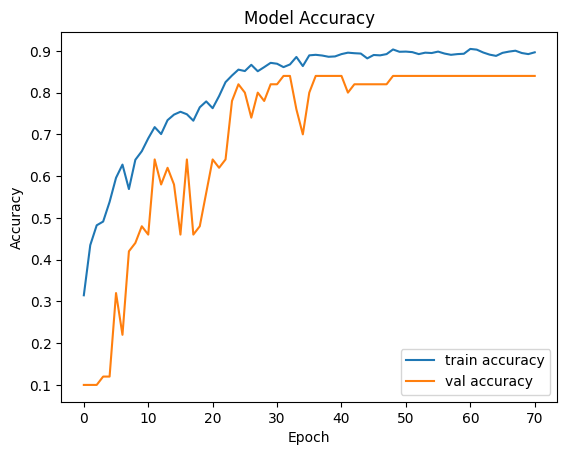

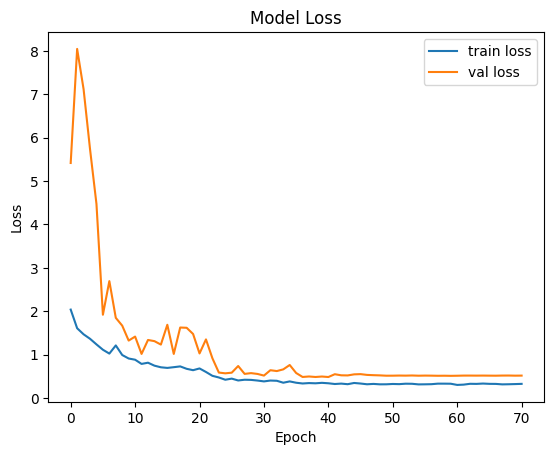

In [4]:
#Plotting Training and Validation Metrics
# Plotting the accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.show()

# Plotting the loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Model Loss')
plt.show()

2/2 [==============================] - 0s 13ms/step
Classification Report
                 precision    recall  f1-score   support

AFRICAN LEOPARD       0.71      1.00      0.83         5
        CARACAL       1.00      1.00      1.00         5
        CHEETAH       1.00      0.80      0.89         5
CLOUDED LEOPARD       0.71      1.00      0.83         5
         JAGUAR       1.00      0.80      0.89         5
          LIONS       1.00      0.80      0.89         5
         OCELOT       1.00      0.60      0.75         5
           PUMA       0.71      1.00      0.83         5
   SNOW LEOPARD       1.00      0.80      0.89         5
          TIGER       1.00      1.00      1.00         5

       accuracy                           0.88        50
      macro avg       0.91      0.88      0.88        50
   weighted avg       0.91      0.88      0.88        50

Confusion Matrix
[[5 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [1 0 4 0 0 0 0 0 0 0]
 [0 0 0 5 0 0 0 0 0 0]
 [1 0 0 0 4 0 0 

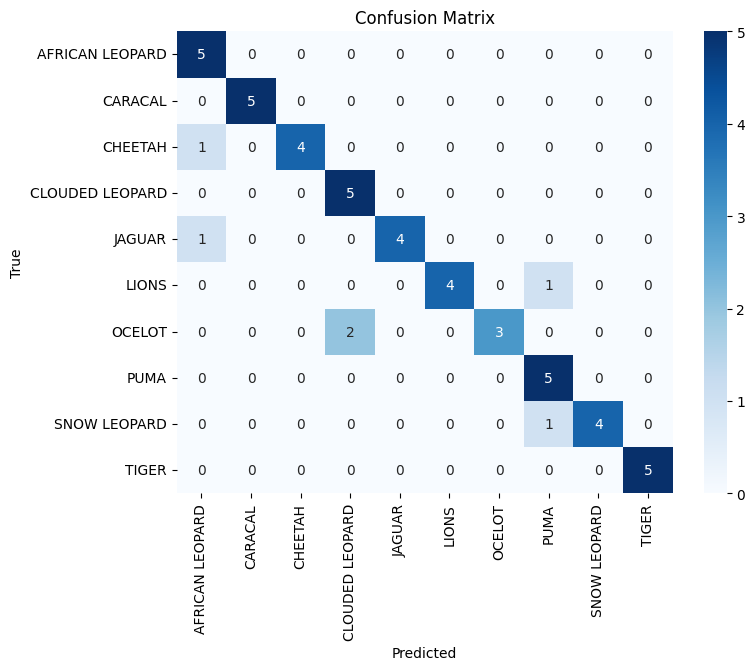

In [18]:
#Evaluating the Model on the Test Set
model.evaluate(test_data, return_dict = True)
model.save(filepath = "model_88.keras")

Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

# Getting the true labels
#y_true = test_data.class_names
y_true = tf.concat([y for x, y in test_data], axis=0)


# Classification report
print('Classification Report')
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix')
print(cm)

# F1 score
f1 = f1_score(y_true, y_pred, average='weighted')
print(f'F1 Score: {f1:.2f}')

# Plotting the confusion matrix
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [16]:
model.evaluate(val_data, return_dict = True)

2/2 [==============================] - 0s 13ms/step - loss: 0.4833 - accuracy: 0.8400


{'loss': 0.4833326041698456, 'accuracy': 0.8399999737739563}

In [17]:
model.evaluate(test_data, return_dict = True)

2/2 [==============================] - 0s 65ms/step - loss: 0.3132 - accuracy: 0.8800


{'loss': 0.31324756145477295, 'accuracy': 0.8799999952316284}

In [19]:
model.evaluate(train_data, return_dict = True)

74/74 [==============================] - 3s 32ms/step - loss: 0.2396 - accuracy: 0.9277


{'loss': 0.23957929015159607, 'accuracy': 0.9277468919754028}